A PyTorch Linear Regression Implementation

This code demonstrates how to implement a simple linear regression model using PyTorch. It generates synthetic data, visualizes it, and defines a linear regression model class.

In [6]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torch.optim as optim

In [7]:
X = torch.randn(100, 1) * 10
y = 2 * X + 1 + torch.randn(100, 1) * 5

In [8]:
class LinearRegression(nn.Module):
    def __init__(self):
        super(LinearRegression, self).__init__()
        self.linear = nn.Linear(1, 1)

    def forward(self, x):
        return self.linear(x)

In [9]:
model = LinearRegression()
print(model)

LinearRegression(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)


Epoch [10/100], Loss: 23.7808
Epoch [20/100], Loss: 23.2147
Epoch [30/100], Loss: 22.7505
Epoch [40/100], Loss: 22.3698
Epoch [50/100], Loss: 22.0575
Epoch [60/100], Loss: 21.8015
Epoch [70/100], Loss: 21.5915
Epoch [80/100], Loss: 21.4193
Epoch [90/100], Loss: 21.2781
Epoch [100/100], Loss: 21.1623


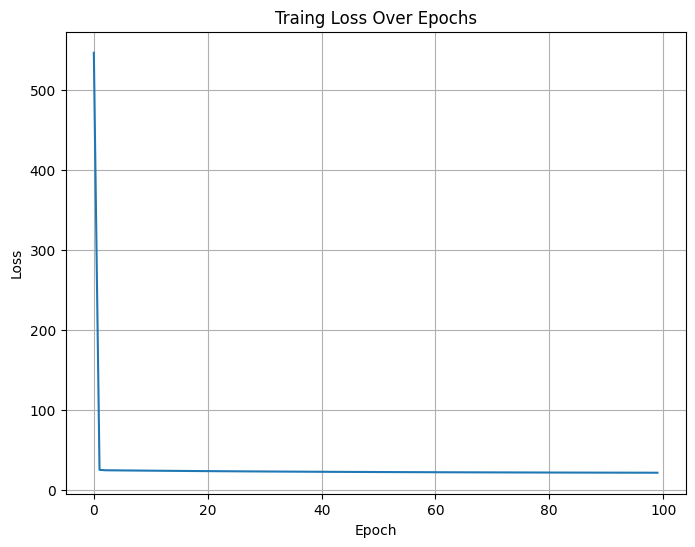

In [10]:
# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.005) # Learning rate = 0.01

# Training loop
num_epochs = 100
losses = []

for epoch in range(0, num_epochs):
    # Forward pass
    outputs = model(X)
    loss = criterion(outputs, y)

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {loss.item():0.4f}')

# Plot the training loss
plt.figure(figsize=(8, 6))
plt.plot(losses)
plt.title('Traing Loss Over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

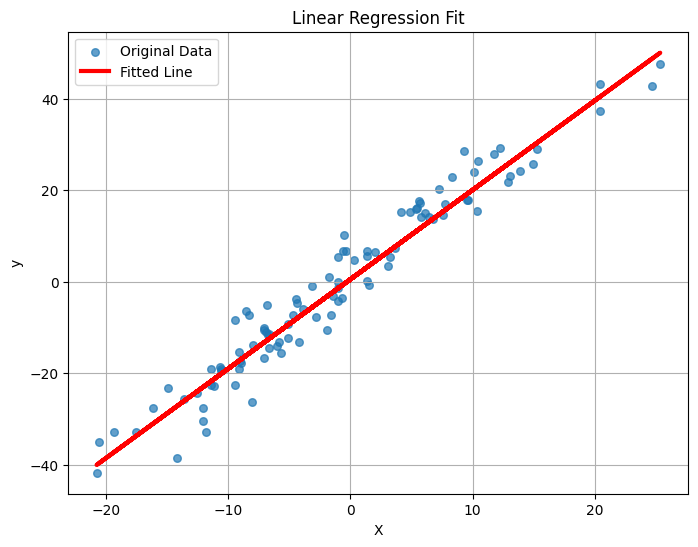

Learned parameters:
Weight (slope): 1.9548
Bias (intercept): 0.5241


In [11]:
# Plot the original data and the trained linear regression line
predicted = model(X).detach().numpy() # Get predictions and convert to numpy

plt.figure(figsize=(8, 6))
plt.scatter(X.numpy(), y.numpy(), s=30, alpha=0.7, label='Original Data')
plt.plot(X.numpy(), predicted, color='red', linewidth=3, label='Fitted Line')
plt.title('Linear Regression Fit')
plt.xlabel('X')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()

# Print the learned parameters
print(f"Learned parameters:")
print(f"Weight (slope): {model.linear.weight.item():.4f}")
print(f"Bias (intercept): {model.linear.bias.item():.4f}")
